In [45]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns
import re
import math
from IPython.display import display, HTML
import html

In [2]:
ROOT_DIR = r"D:\implementation\p2psta\implementation\results"  
RUN_NAME = None  # 例如 "run_20250917_134512"; 设为 None 则按修改时间自动选最新的 run_*

def pick_run(root_dir: str, run_name: str | None = None) -> Path | None:
    root = Path(root_dir)
    if run_name:
        rd = root / run_name
        return rd if rd.exists() else None
    runs = sorted(
        [p for p in root.glob("run_*") if p.is_dir()],
        key=lambda p: p.stat().st_mtime,
        reverse=True
    )
    return runs[0] if runs else None

RUN_DIR = pick_run(ROOT_DIR, RUN_NAME)
print("Using RUN_DIR:", RUN_DIR)
if RUN_DIR is None:
    raise FileNotFoundError("No run_* folder found. ")

Using RUN_DIR: D:\implementation\p2psta\implementation\results\run_20250918_220808


### Parameters and Timings Explanation

- **[Global Config]**
  - `data.csv_path`: Path to the dataset file used for ingestion.
  - `data.max_ingest`: Maximum number of records to ingest (`None` means all records).

- **[SFC Config]**
  - `algorithm`: Space-filling curve used (`z3` = 3D Z-order).
  - `center_lat`: Reference latitude for distance-to-meter conversion.
  - `x_precision_m`, `y_precision_m`: Spatial resolution in meters for X (longitude) and Y (latitude).
  - `t_precision_s`: Temporal resolution in seconds.
  - `derived_bits`: Bit lengths (`lx`, `ly`, `lt`) used for encoding; `ring_m` is the total key length for the DHT ring.
  - `global_lat`, `global_lon`, `global_time`: Bounding box of the dataset in latitude, longitude, and time.

- **[Experiment Config]**
  - `stop_tail_bits`: Controls granularity of range decomposition; smaller values = finer ranges.
  - `merge_gap_keys`: Threshold for merging small gaps between ranges (to reduce fragmentation).
  - `max_ranges`: Maximum number of ranges allowed per query (`None` = unlimited).

- **[Metrics]**
  - `precise_hits`: Whether precise post-filtering of results is enabled.
  - `save_with_nodes`: Whether query results are saved with node-level details.

- **[Queries]**
  - Total number of queries run in the experiment.
  - Each query includes: name, spatial bounding box (`lat`, `lon`), and temporal window (`time`).

- **Timings**
  - `ingest_ms`: Time spent ingesting all data (milliseconds).
  - `query[<name>]_ms`: Execution time of each query in milliseconds.


In [3]:
params_path = Path(RUN_DIR) / "params.txt"
timings_path = Path(RUN_DIR) / "timings.txt"

with open(params_path, "r", encoding="utf-8") as f:
    params_text = f.read()

with open(timings_path, "r", encoding="utf-8") as f:
    timings_text = f.read()

print(params_text)
print('...')
print(timings_text)


[Global Config]
data.csv_path=geolife_clean.csv
data.max_ingest=None

[SFC Config]
algorithm=z3
center_lat=39.9
time_bucket_s=None
max_ranges=None
max_depth=Some(20)
max_nodes=Some(50000)
tail_bits_guard=Some(12)
derived_bits: lx=10 ly=10 lt=10 ring_m=30
global_lat=[39, 41] global_lon=[115, 118] global_time=[1176268800, 1343433600]

[Experiment Config]
stop_tail_bits=6
merge_gap_keys=65536
max_ranges=None

[Metrics]
precise_hits=Some(true)
save_with_nodes=Some(true)

[Queries] total=2
Q00: name=Some("forbidden_city"), lat=[39.906,39.923], lon=[116.386,116.411], time=[2008-06-01T03:00:00Z,2010-06-10T03:15:00Z]
Q01: name=Some("beijing"), lat=[39.5,40.2], lon=[116,116.8], time=[2008-05-10T22:00:00Z,2012-05-20T01:00:00Z]

...
ingest_ms=15454
query[forbidden_city]_ms=97
query[beijing]_ms=25408



### About node_distribution.csv
This file summarizes how data is distributed across nodes in the DHT ring.

- **pnode_idx**: Index of the node in the experiment (0-based).  
- **node_id**: Identifier of the node on the DHT ring.  
- **total_count**: Number of records stored on this node.  
- **min_key**: Smallest key value stored on this node.  
- **max_key**: Largest key value stored on this node.  
- **key_span** (derived): The difference between `max_key` and `min_key`, indicating the portion of key space covered by the node.

In [4]:
csv_path = Path(RUN_DIR) / "node_distribution.csv"
if not csv_path.exists():
    raise FileNotFoundError(f"node_distribution.csv not found at: {csv_path}")

# 读取 CSV；把空白当作缺失值处理
df = pd.read_csv(
    csv_path,
    dtype={"pnode_idx": "Int64", "node_id": "Int64", "total_count": "Int64"},
    na_values=["", " ", "NA", "NaN"]
)

# 确保 min_key / max_key 为可空整型；缺失保持 NaN
for col in ["min_key", "max_key"]:
    df[col] = pd.to_numeric(df[col], errors="coerce").astype("Int64")

# 计算 key_span（max_key - min_key）；缺失用 0
df["key_span"] = (df["max_key"] - df["min_key"]).astype("Int64")
df["key_span"] = df["key_span"].fillna(0)


df.head() 




,pnode_idx,node_id,total_count,min_key,max_key,key_span
0,0,0,0,<NA>,<NA>,0
1,1,1048576,0,<NA>,<NA>,0
2,2,2097152,0,<NA>,<NA>,0
3,3,3145728,0,<NA>,<NA>,0
4,4,4194304,0,<NA>,<NA>,0


### Figure 1: Records per node
This chart shows the total number of records (`total_count`) stored on each node.  
- **X-axis:** Node index (`pnode_idx`)  
- **Y-axis:** Number of records stored  
The purpose of this figure is to reveal how evenly the data records are distributed across nodes. A balanced distribution indicates good load balancing, while large differences suggest potential hotspots.


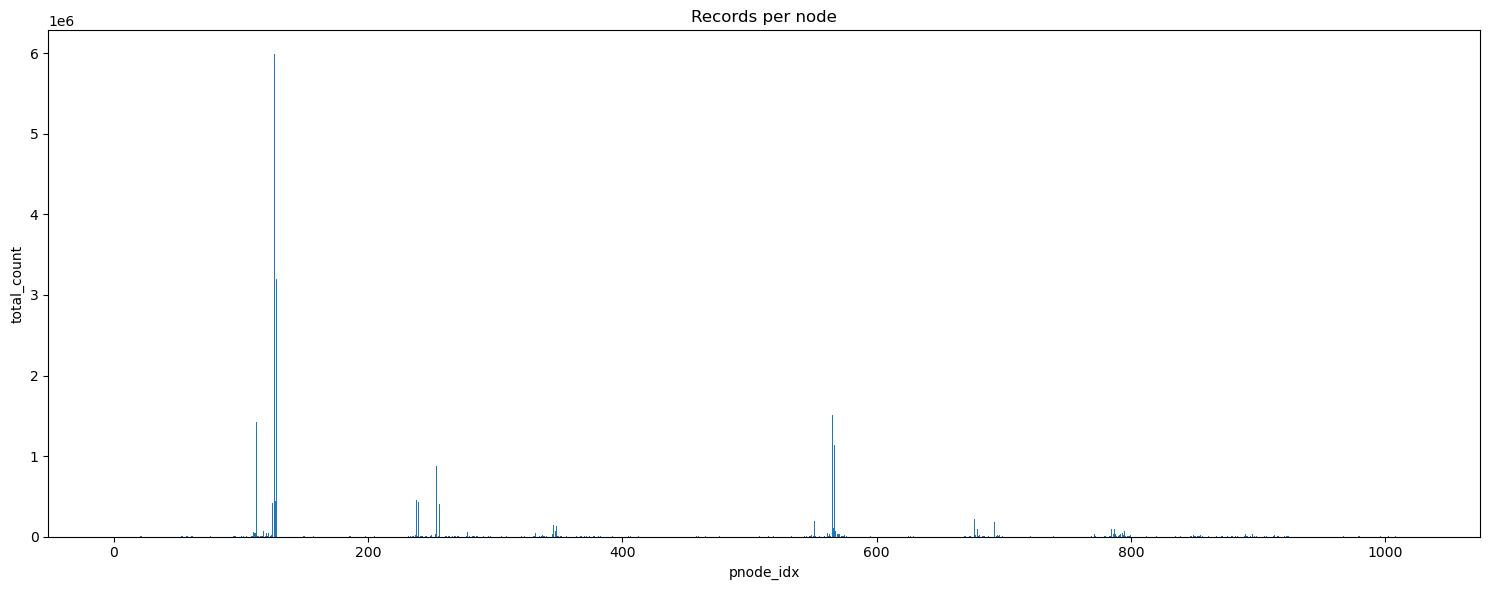

In [5]:
# --- 图1：每个 node 的 total_count ---
plt.figure(figsize=(15, 6))
plt.bar(df["pnode_idx"].fillna(0).astype(int), df["total_count"].fillna(0).astype(int))
plt.xlabel("pnode_idx")
plt.ylabel("total_count")
plt.title("Records per node")
plt.tight_layout()
plt.show()


### Figure 2: Key span per node
This chart illustrates the key range assigned to each node, computed as `max_key - min_key`.  
- **X-axis:** Node index (`pnode_idx`)  
- **Y-axis:** Key span size  
This figure highlights how the key space is partitioned among the nodes. Large variations in span size imply that some nodes cover significantly larger portions of the key space, which may affect query routing and balance.


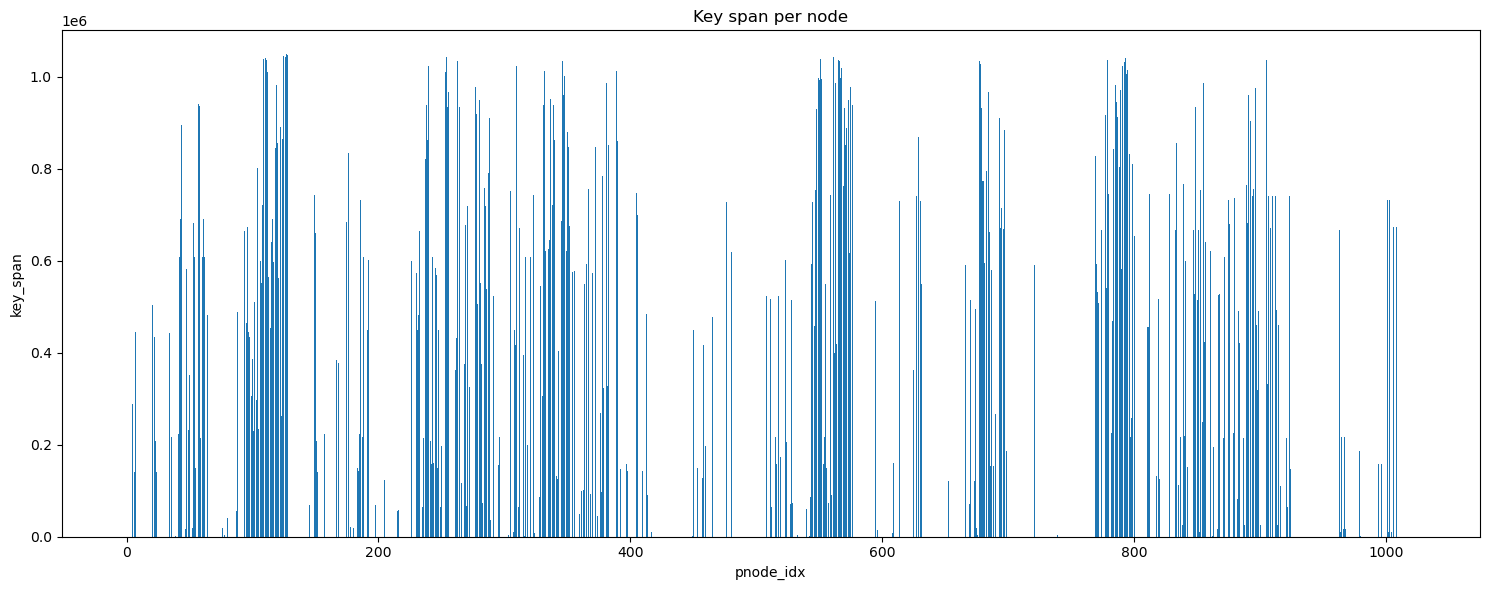

In [6]:
# --- 图2：每个 node 的 key_span（max_key - min_key）---
plt.figure(figsize=(15, 6))
plt.bar(df["pnode_idx"].fillna(0).astype(int), df["key_span"].fillna(0).astype(int))
plt.xlabel("pnode_idx")
plt.ylabel("key_span")
plt.title("Key span per node")
plt.tight_layout()
plt.show()

### About nodes_dump.csv
This file lists all trajectory points stored on each node.

- **pnode_idx**: Index of the node where the record is stored.  
- **node_id**: Identifier of the node on the DHT ring.  
- **key**: Encoded SFC key of the point.  
- **user**: User ID to which the trajectory belongs.  
- **traj_id**: Identifier of the trajectory sequence.  
- **lat**: Latitude of the trajectory point.  
- **lon**: Longitude of the trajectory point.  
- **datetime**: Timestamp of the trajectory point (ISO-8601 format).


In [7]:
csv_path = Path(RUN_DIR) / "nodes_dump.csv"
if not csv_path.exists():
    raise FileNotFoundError(f"nodes_dump.csv not found at: {csv_path}")

# 读取数据
df = pd.read_csv(
    csv_path,
    dtype={"pnode_idx": "Int64", "node_id": "Int64", "key": "Int64", "user": "Int64", "traj_id": "Int64"},
    parse_dates=["datetime"]
)

print("Rows:", len(df))
df.head(10)

Rows: 19632236


,pnode_idx,node_id,key,user,traj_id,lat,lon,datetime
0,5,5242880,4941349,21,-4971020989573314408,39.101050,115.727933,2007-04-29 15:32:17+00:00
1,5,5242880,4941573,21,-4971020989573314408,39.103983,115.729233,2007-04-29 15:32:09+00:00
2,5,5242880,4943409,21,-4971020989573314408,39.114500,115.735967,2007-04-29 15:31:34+00:00
3,5,5242880,5021768,10,-4615239167271405175,39.000208,115.612657,2007-10-21 20:07:00+00:00
4,5,5242880,5021770,10,-4615239167271405175,39.000673,115.613095,2007-10-21 20:07:02+00:00
5,5,5242880,5021770,10,-4615239167271405175,39.000907,115.613315,2007-10-21 20:07:03+00:00
6,5,5242880,5021770,10,-4615239167271405175,39.001140,115.613535,2007-10-21 20:07:04+00:00
7,5,5242880,5021770,10,-4615239167271405175,39.001605,115.613973,2007-10-21 20:07:06+00:00
8,5,5242880,5021770,10,-4615239167271405175,39.001838,115.614193,2007-10-21 20:07:07+00:00
9,5,5242880,5021774,10,-4615239167271405175,39.002307,115.614633,2007-10-21 20:07:09+00:00


### Figure 1: Trajectory points (scatter plot)
This scatter plot shows the geographic distribution of all trajectory points stored in the selected node dump.  
- **X-axis:** Longitude  
- **Y-axis:** Latitude  
The figure helps to visualize the spatial footprint of the stored data and check whether the points correspond to realistic trajectories.


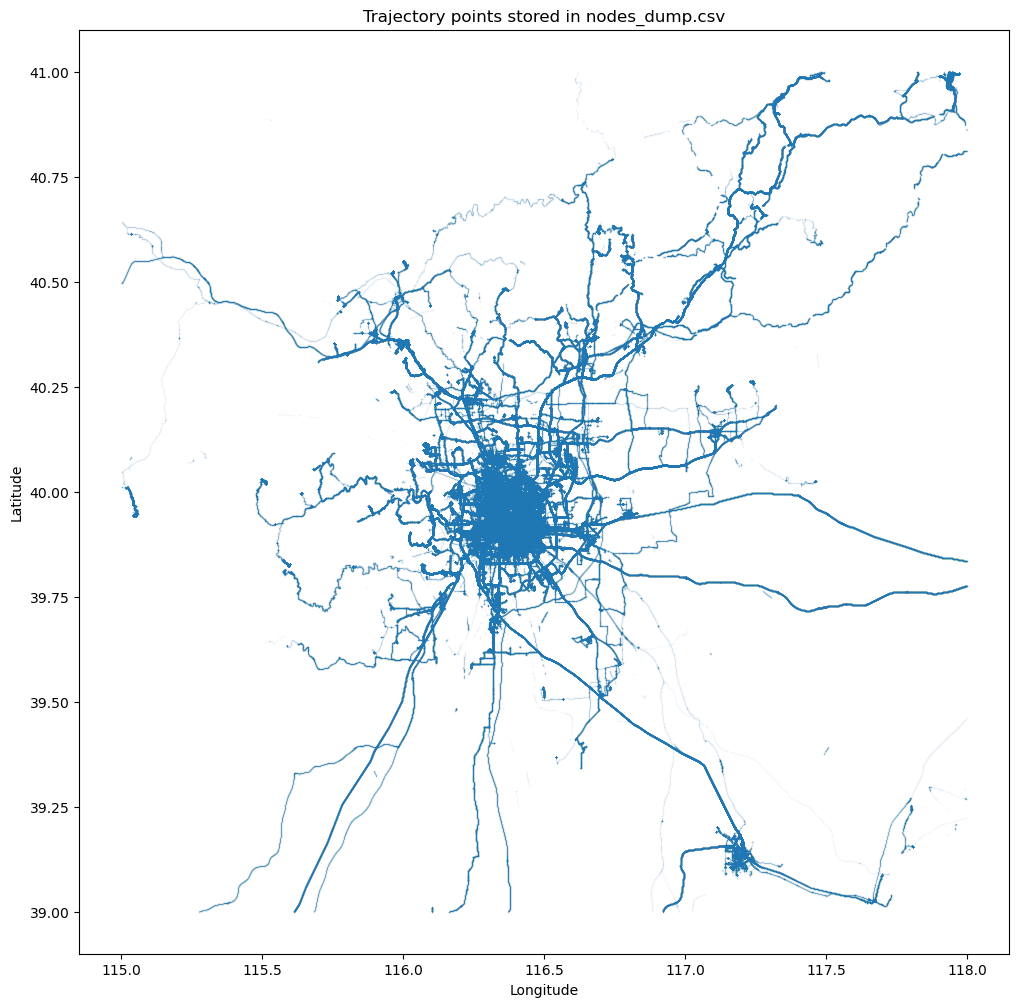

In [8]:
plt.figure(figsize=(12,12))
plt.scatter(df["lon"], df["lat"], s=1, alpha=0.05,linewidth=0)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Trajectory points stored in nodes_dump.csv")
plt.show()

### Figure 2: Trajectory timeline
This plot shows how latitude and longitude values evolve over time.  
- **X-axis:** Timestamp (`datetime`)  
- **Y-axis:** Latitude and Longitude values  
The figure helps to inspect the temporal continuity of trajectories and identify gaps or irregular sampling intervals.


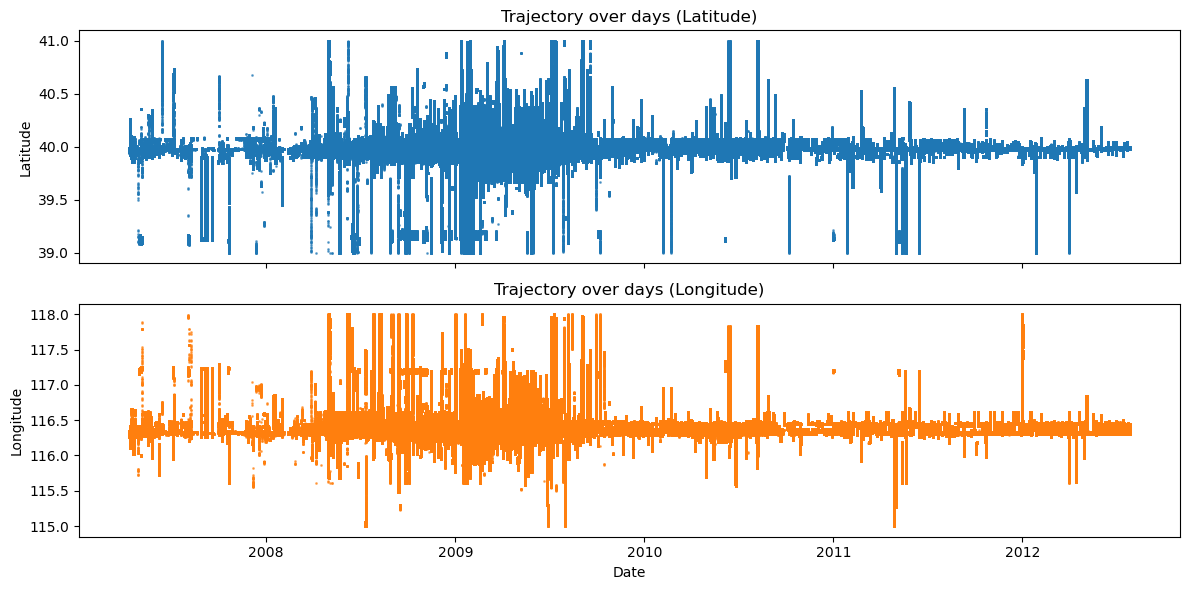

In [9]:
df["date"] = df["datetime"].dt.date  # 只取年月日

fig, axs = plt.subplots(2, 1, figsize=(12,6), sharex=True)

axs[0].plot(df["date"], df["lat"], ".", markersize=2, alpha=0.6, color="tab:blue")
axs[0].set_ylabel("Latitude")
axs[0].set_title("Trajectory over days (Latitude)")

axs[1].plot(df["date"], df["lon"], ".", markersize=2, alpha=0.6, color="tab:orange")
axs[1].set_ylabel("Longitude")
axs[1].set_xlabel("Date")
axs[1].set_title("Trajectory over days (Longitude)")

plt.tight_layout()
plt.show()

### Figure 3: Points per user
This bar chart shows the number of trajectory points stored for each user ID.  
- **X-axis:** User identifier (`user`)  
- **Y-axis:** Count of trajectory points  
The figure highlights how data is distributed across users, revealing whether some users dominate the dataset.


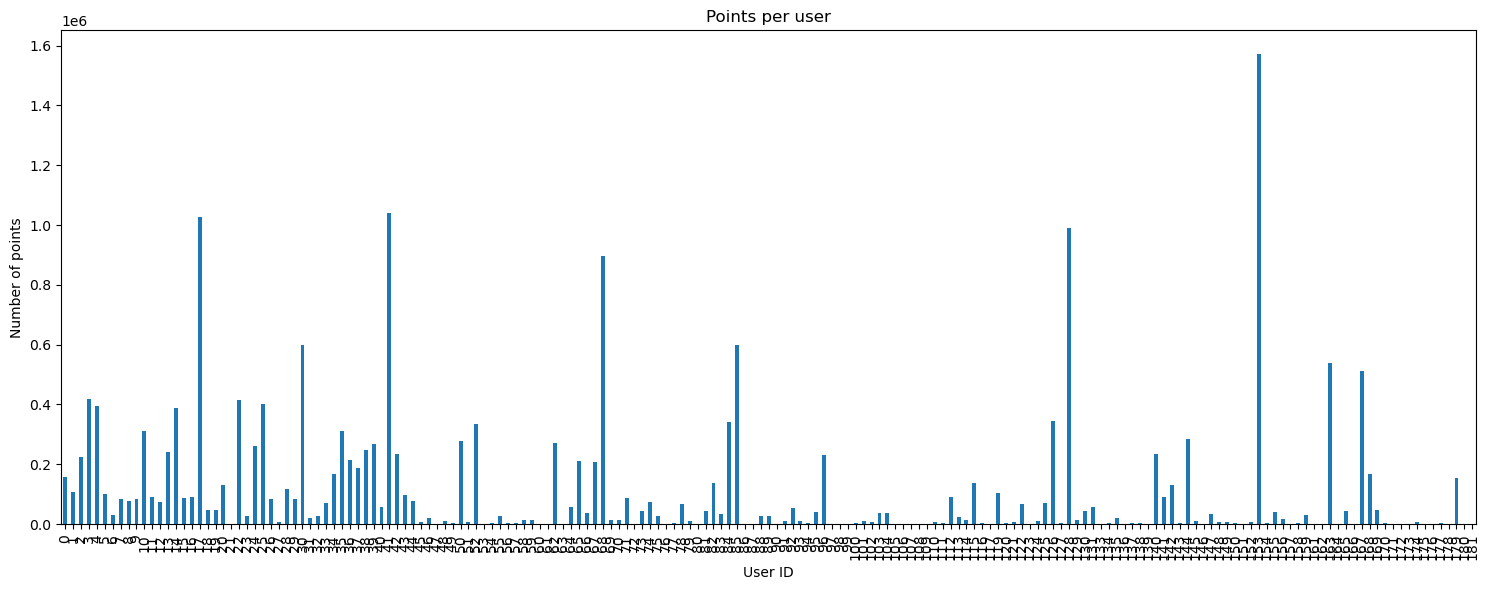

In [10]:
if "user" in df.columns:
    counts = df.groupby("user").size()
    counts.plot(kind="bar", figsize=(15,6))
    plt.xlabel("User ID")
    plt.ylabel("Number of points")
    plt.title("Points per user")
    plt.tight_layout()
    plt.show()

### About node_ranges.csv
This file describes each node's responsibility interval on the key ring and the data actually stored within that interval.

- **pnode_idx**: Index of the node in the experiment (0-based).
- **node_id**: Identifier of the node on the DHT ring.
- **resp_start**: Start of the responsibility interval on the ring (in key space).
- **resp_end**: End of the responsibility interval on the ring (in key space).
- **wrapped**: Whether the interval wraps around the zero point of the ring (if `true`, the interval is split across the end and the beginning of the ring).
- **stored_total**: Number of records actually stored on this node.
- **stored_min**: Minimum key of stored records on this node (if any).
- **stored_max**: Maximum key of stored records on this node (if any).

> Note: The ring size is `2^ring_m`, where `ring_m` is read from `params.txt`. The effective interval length is computed modulo the ring size.


In [11]:
csv_path = Path(RUN_DIR) / "node_ranges.csv"
if not csv_path.exists():
    raise FileNotFoundError(f"node_ranges.csv not found at: {csv_path}")

df = pd.read_csv(
    csv_path,
    dtype={
        "pnode_idx": "Int64",
        "node_id": "Int64",
        "resp_start": "Int64",
        "resp_end": "Int64",
        "stored_total": "Int64",
        "stored_min": "Int64",
        "stored_max": "Int64",
    },
    na_values=["", " ", "NA", "NaN"]
)

# 规范 wrapped 布尔列
if "wrapped" in df.columns:
    df["wrapped"] = df["wrapped"].astype(str).str.lower().map({"true": True, "false": False})
else:
    df["wrapped"] = False

# ---- 解析 ring_m（来自 params.txt），计算环长 ----
params_path = Path(RUN_DIR) / "params.txt"
if not params_path.exists():
    raise FileNotFoundError(f"params.txt not found at: {params_path} (needed to parse ring_m)")

params_text = params_path.read_text(encoding="utf-8", errors="ignore")
m = re.search(r"ring_m\s*=\s*(\d+)", params_text)
if not m:
    raise ValueError("Unable to parse ring_m from params.txt (expected like 'ring_m=39').")
ring_m = int(m.group(1))
ring_size = 1 << ring_m

print(f"ring_m = {ring_m}, ring_size = {ring_size}")

# ---- 计算责任跨度（模环长）----
# exclusive 跨度： (end - start) mod ring_size
resp_span_excl = (df["resp_end"].astype("Int64") - df["resp_start"].astype("Int64")) % ring_size
df["resp_span"] = resp_span_excl.astype("Int64")
# 也可以给出 inclusive 的跨度（+1），但作图用 resp_span 更直观
df["resp_span_inclusive"] = (df["resp_span"] + 1).astype("Int64")

# 存储区间跨度（若存在）
df["stored_span"] = (df["stored_max"] - df["stored_min"]).astype("Int64")
df["stored_span"] = df["stored_span"].fillna(0)

# 排序（按 pnode_idx）
df = df.sort_values("pnode_idx").reset_index(drop=True)
df.head()

ring_m = 30, ring_size = 1073741824


,pnode_idx,node_id,resp_start,resp_end,wrapped,stored_total,stored_min,stored_max,resp_span,resp_span_inclusive,stored_span
0,0,0,1072693249,0,True,0,<NA>,<NA>,1048575,1048576,0
1,1,1048576,1,1048576,False,0,<NA>,<NA>,1048575,1048576,0
2,2,2097152,1048577,2097152,False,0,<NA>,<NA>,1048575,1048576,0
3,3,3145728,2097153,3145728,False,0,<NA>,<NA>,1048575,1048576,0
4,4,4194304,3145729,4194304,False,0,<NA>,<NA>,1048575,1048576,0


### Figure 1: Stored records per node
This bar chart shows the number of records stored on each node (`stored_total`).
- **X-axis:** Node index (`pnode_idx`)
- **Y-axis:** Number of stored records
Use this figure to assess load balance. Significant differences may indicate hotspots or skewed placement.


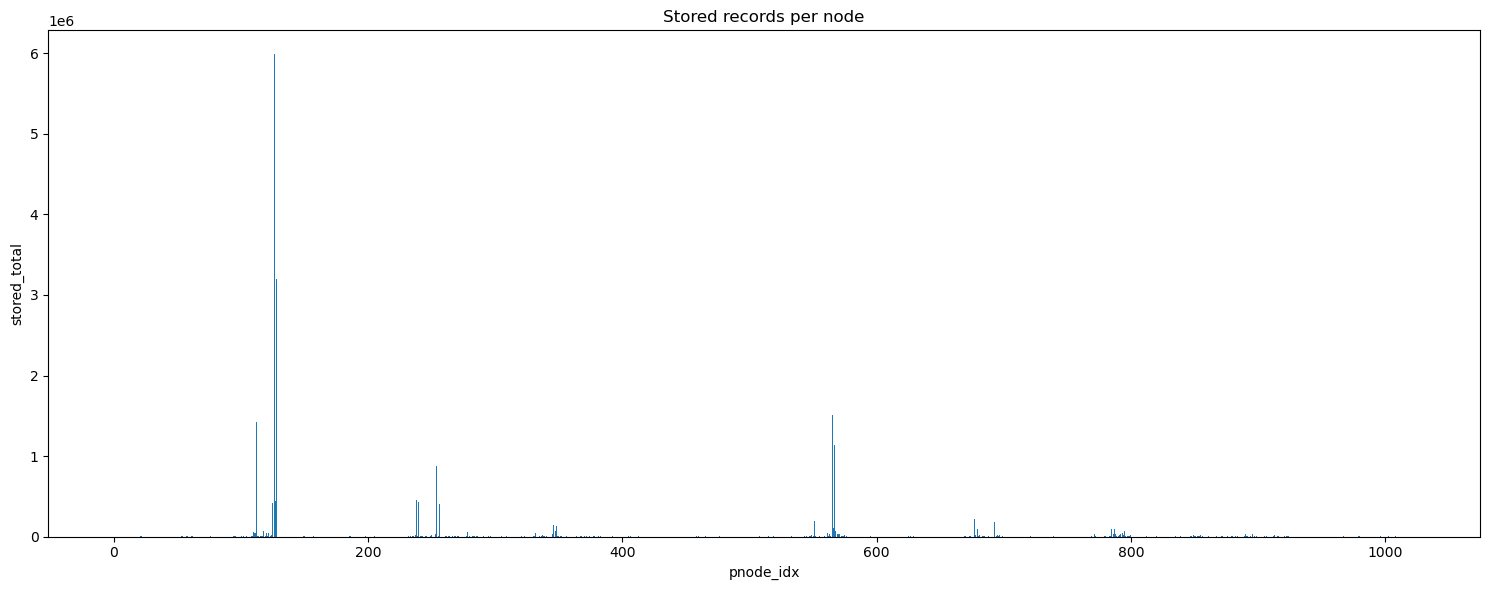

In [12]:
plt.figure(figsize=(15, 6))
plt.bar(df["pnode_idx"].astype(int), df["stored_total"].fillna(0).astype(int))
plt.xlabel("pnode_idx")
plt.ylabel("stored_total")
plt.title("Stored records per node")
plt.tight_layout()
plt.show()

### Figure 2: Responsibility span per node
This bar chart shows the size of each node's responsibility interval on the ring, computed as `(resp_end - resp_start) mod ring_size`.
- **X-axis:** Node index (`pnode_idx`)
- **Y-axis:** Responsibility span (in key counts)
If some nodes cover much larger spans than others, the ring partitioning may be uneven, which can affect routing and load balance.


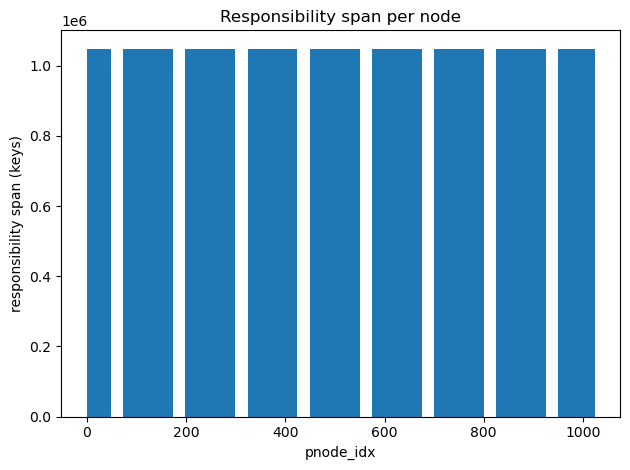

In [13]:
plt.figure()
plt.bar(df["pnode_idx"].astype(int), df["resp_span"].astype("Int64").fillna(0).astype(int))
plt.xlabel("pnode_idx")
plt.ylabel("responsibility span (keys)")
plt.title("Responsibility span per node")
plt.tight_layout()
plt.show()

### Figure 3: Responsibility ranges on the ring
This figure illustrates each node’s responsibility interval as a horizontal segment on the key ring. If an interval wraps around the ring’s zero point, it is drawn as two segments (from `resp_start` to the ring end, and from zero to `resp_end`).
- **X-axis:** Ring key
- **Y-axis:** Node index (`pnode_idx`)
This visualization helps validate that node intervals tile the ring without gaps or overlaps, and clarifies where wrapped intervals occur.

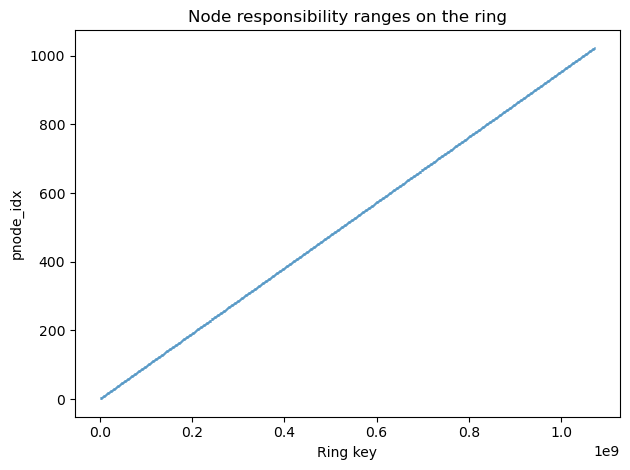

In [14]:
plt.figure()
y_vals = df["pnode_idx"].astype(int).tolist()
for _, r in df.iterrows():
    y = int(r["pnode_idx"])
    start = int(r["resp_start"])
    end = int(r["resp_end"])
    wrapped = bool(r["wrapped"])

    if not wrapped:
        # 普通情况： [start, end)
        plt.hlines(y=y, xmin=start, xmax=end, linewidth=2)
    else:
        # 跨零点：分两段 [start, ring_size) 和 [0, end)
        plt.hlines(y=y, xmin=start, xmax=ring_size, linewidth=2)
        plt.hlines(y=y, xmin=0, xmax=end, linewidth=2)

plt.xlabel("Ring key")
plt.ylabel("pnode_idx")
plt.title("Node responsibility ranges on the ring")
plt.tight_layout()
plt.show()

### Original data file

In [15]:
CSV_PATH = 'D:\implementation\p2psta\implementation\geolife_clean.csv' 
# ===== 1. 读数据 =====
df = pd.read_csv(
    CSV_PATH,
    parse_dates=['datetime'],
    dtype={'user': 'category'}
)
df.head()

<>:1: SyntaxWarning: invalid escape sequence '\i'
<>:1: SyntaxWarning: invalid escape sequence '\i'
C:\Users\yezhan\AppData\Local\Temp\ipykernel_26484\1541564178.py:1: SyntaxWarning: invalid escape sequence '\i'
  CSV_PATH = 'D:\implementation\p2psta\implementation\geolife_clean.csv'


,user,traj_id,lat,lon,datetime
0,000,000/20081023025304,39.984702,116.318417,2008-10-22 18:53:04+00:00
1,000,000/20081023025304,39.984683,116.318450,2008-10-22 18:53:10+00:00
2,000,000/20081023025304,39.984686,116.318417,2008-10-22 18:53:15+00:00
3,000,000/20081023025304,39.984688,116.318385,2008-10-22 18:53:20+00:00
4,000,000/20081023025304,39.984655,116.318263,2008-10-22 18:53:25+00:00


In [16]:
t_min, t_max = df.datetime.min(), df.datetime.max()
lat_min, lat_max = df.lat.min(), df.lat.max()
lon_min, lon_max = df.lon.min(), df.lon.max()

print(f'row : {len(df):,}')
print(f'Total days        : {(t_max - t_min).days + 1} days')
print(f'Time span      : {t_min}  ——  {t_max}')
print(f'Latitude range      : {lat_min:.6f}  –  {lat_max:.6f}')
print(f'Longitude range     : {lon_min:.6f}  –  {lon_max:.6f}')

row : 19,632,236
Total days        : 1933 days
Time span      : 2007-04-12 01:31:32+00:00  ——  2012-07-27 00:31:20+00:00
Latitude range      : 39.000000  –  40.999996
Longitude range     : 115.000173  –  117.999978


### Time distribution of data

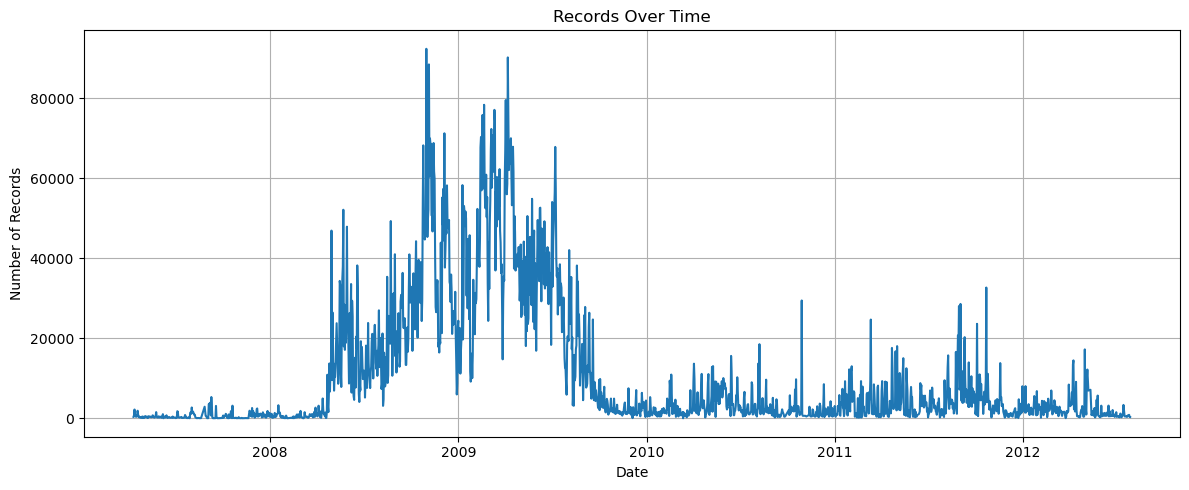

In [17]:
df['date'] = df['datetime'].dt.date
date_counts = df['date'].value_counts().sort_index()
plt.figure(figsize=(12, 5))
plt.plot(date_counts.index, date_counts.values, linestyle='-')
plt.xlabel('Date')
plt.ylabel('Number of Records')
plt.title('Records Over Time')
plt.grid(True)
plt.tight_layout()
plt.show()

### Spatial distribution of data

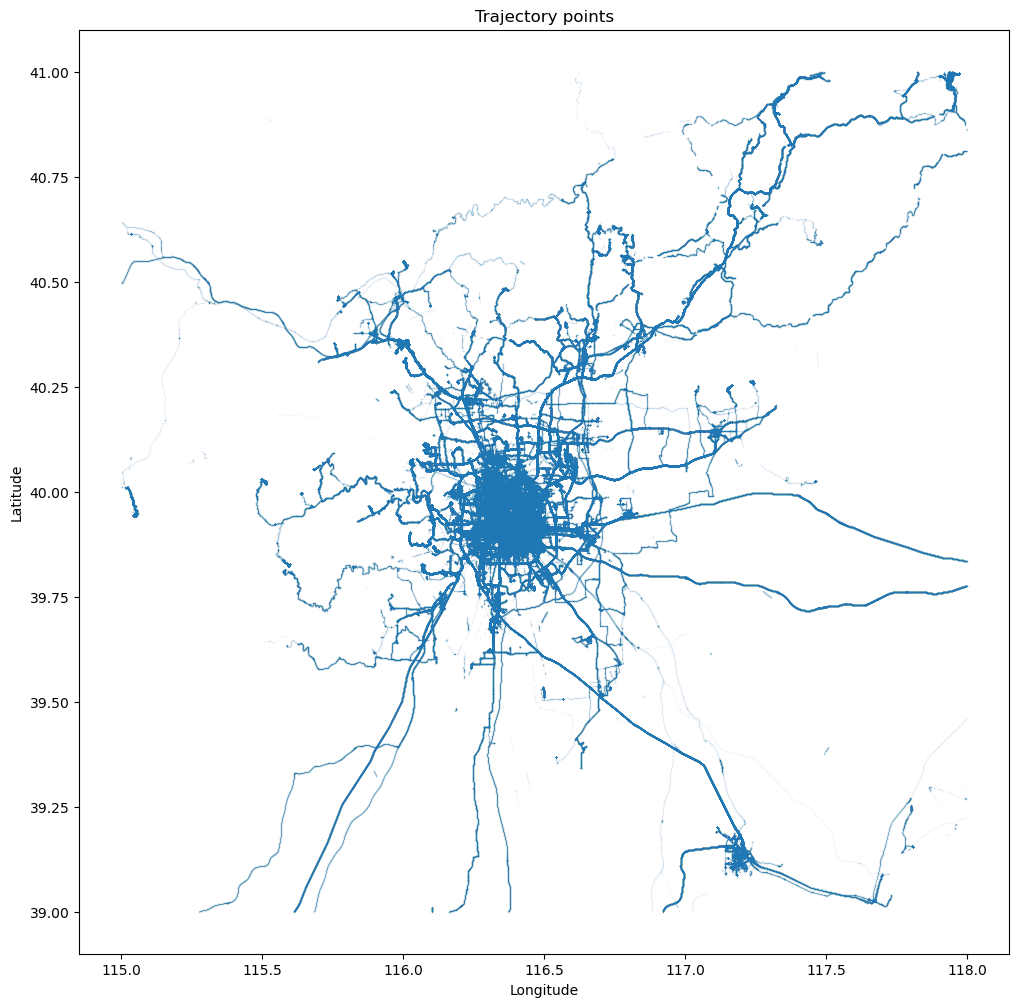

In [18]:
plt.figure(figsize=(12,12))
plt.scatter(df["lon"], df["lat"], s=1, alpha=0.05,linewidth=0)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Trajectory points")
plt.show()

#### The actual data within the query range in the original dataset

In [19]:
QUERIES = {
    'forbidden_city': {
        'lat_min': 39.906, 'lat_max': 39.923,
        'lon_min': 116.386, 'lon_max': 116.411,
        't_start': pd.Timestamp('2008-06-01 03:00:00', tz='UTC'),
        't_end': pd.Timestamp('2010-06-10 03:15:00', tz='UTC')
    },
    'beijing': {
        'lat_min': 39.5, 'lat_max': 40.2,
        'lon_min': 116.0, 'lon_max': 116.8,
        't_start': pd.Timestamp('2008-05-10 22:00:00', tz='UTC'),
        't_end': pd.Timestamp('2012-05-20 01:00:00', tz='UTC')
    }
}

def summarize(df, queries):
    """return dict：{query_name: {rows, users, trajs, first, last}}"""
    summary = {}
    for name, q in queries.items():
        mask = (
            (df.lat >= q['lat_min']) & (df.lat <= q['lat_max']) &
            (df.lon >= q['lon_min']) & (df.lon <= q['lon_max']) &
            (df.datetime >= q['t_start']) & (df.datetime <= q['t_end'])
        )
        sub = df[mask]
        summary[name] = {
            'rows': int(mask.sum()),
            'users': sub['user'].nunique(),
            'trajs': sub['traj_id'].nunique(),
            'first': sub['datetime'].min(),
            'last': sub['datetime'].max()
        }
    return summary

summary = summarize(df, QUERIES)
for name, s in summary.items():
    print(f"\n=== {name} ===")
    print(f"rows : {s['rows']}")
    print(f"users: {s['users']}")
    print(f"trajs: {s['trajs']}")
    print(f"time : {s['first']}  ~  {s['last']}")

# 顺便打印全表指标
print('\n=== full file ===')
print(f'total rows : {len(df)}')
print(f'total users: {df["user"].nunique()}')
print(f'total trajs: {df["traj_id"].nunique()}')
print(f'time range : {df["datetime"].min()}  ~  {df["datetime"].max()}')


=== forbidden_city ===
rows : 52649
users: 50
trajs: 216
time : 2008-06-05 01:45:44+00:00  ~  2010-06-04 03:13:41+00:00

=== beijing ===
rows : 17999400
users: 139
trajs: 15385
time : 2008-05-10 22:00:00+00:00  ~  2012-05-19 11:55:15+00:00

=== full file ===
total rows : 19632236
total users: 179
total trajs: 17314
time range : 2007-04-12 01:31:32+00:00  ~  2012-07-27 00:31:20+00:00


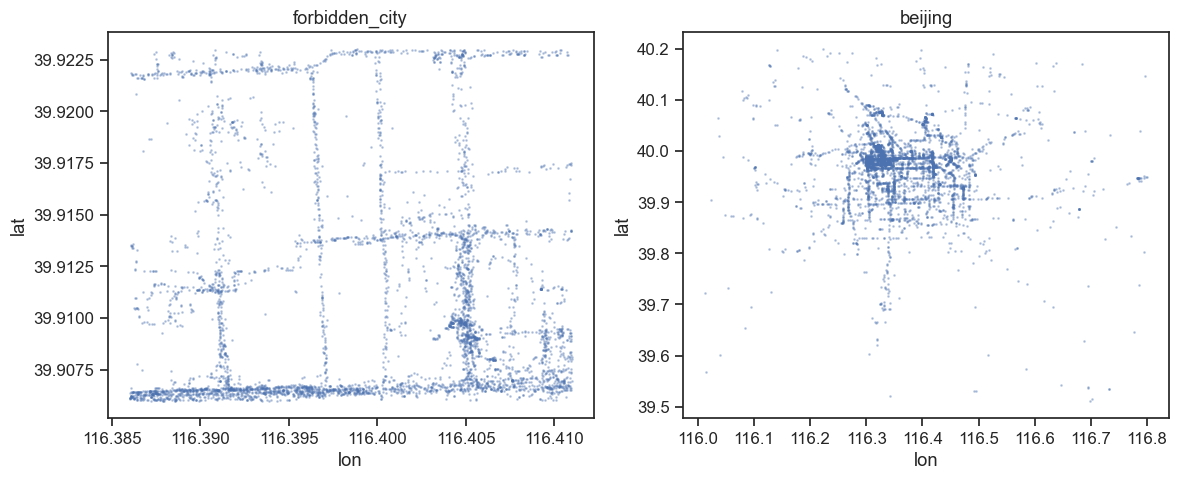

In [20]:
sns.set(style="ticks", font_scale=1.1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (name, q) in zip(axes, QUERIES.items()):
    # 1. 先过滤
    mask = (
        (df.lat >= q['lat_min']) & (df.lat <= q['lat_max']) &
        (df.lon >= q['lon_min']) & (df.lon <= q['lon_max']) &
        (df.datetime >= q['t_start']) & (df.datetime <= q['t_end'])
    )
    sub = df[mask]                  
    if sub.empty:                        
        print(f'{name} no data in range, skipping plot.')
        continue
    # 4. 再抽样
    sub = sub.sample(n=min(5000, len(sub)), random_state=42)
    ax.scatter(sub.lon, sub.lat, s=1, alpha=0.3)
    ax.set_title(name)
    ax.set_xlabel('lon')
    ax.set_ylabel('lat')

plt.tight_layout()
plt.show()

#### Query results of project

In [21]:
queries = {
    "forbidden_city": Path(RUN_DIR) / "query_00_forbidden_city",
    "beijing":         Path(RUN_DIR) / "query_01_beijing",
}

files = {
    name: qdir / "query_results.csv"
    for name, qdir in queries.items()
}

dfs = {}
for name, path in files.items():
    df = pd.read_csv(
        path,
        parse_dates=['datetime'],
        dtype={'traj_id': str}
    )
    df['traj_id'] = df['traj_id'].str.strip()

    dfs[name] = df
    
summary = {}
for name, df in dfs.items():
    summary[name] = {
        'rows': len(df),
        'users': df['user'].nunique(),
        'trajs': df['traj_id'].nunique(),
        'first': df['datetime'].min(),
        'last': df['datetime'].max()
    }

for name, s in summary.items():
    print(f'\n=== {name} ===')
    print(f"rows : {s['rows']}")
    print(f"users: {s['users']}")
    print(f"trajs: {s['trajs']}")
    print(f"time : {s['first']}  ~  {s['last']}")


=== forbidden_city ===
rows : 52649
users: 50
trajs: 216
time : 2008-06-05 01:45:44+00:00  ~  2010-06-04 03:13:41+00:00

=== beijing ===
rows : 17999400
users: 139
trajs: 15385
time : 2008-05-10 22:00:00+00:00  ~  2012-05-19 11:55:15+00:00


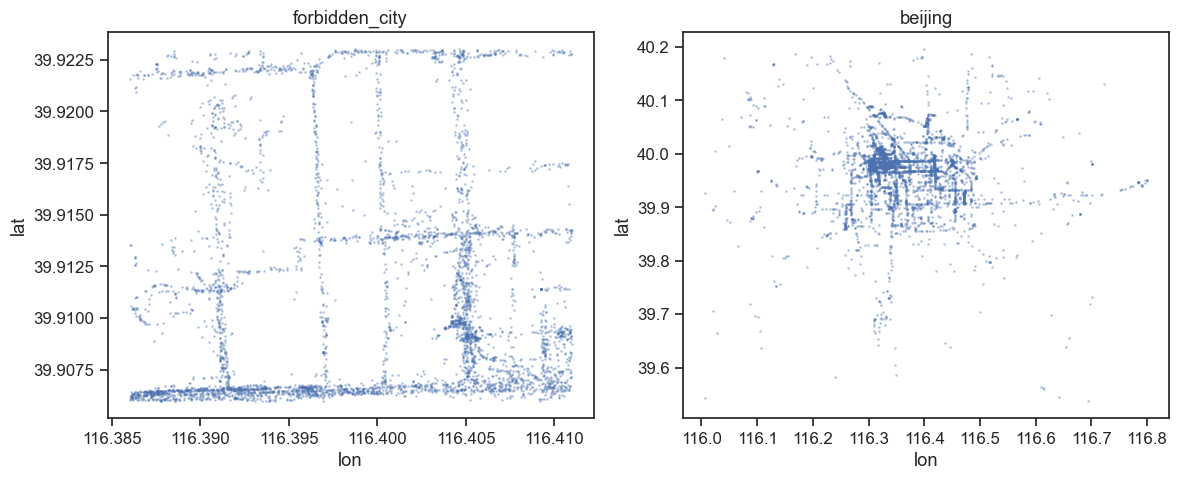

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (name, df) in zip(axes, dfs.items()):
    if df.empty:
        ax.set_title(f'{name} no data')
        continue
    plot_df = df.sample(n=min(5000, len(df)), random_state=42)
    ax.scatter(plot_df.lon, plot_df.lat, s=1, alpha=0.3)
    ax.set_title(name)
    ax.set_xlabel('lon')
    ax.set_ylabel('lat')

plt.tight_layout()
plt.show()

In [46]:

queries = {
    "forbidden_city": Path(RUN_DIR) / "query_00_forbidden_city",
    "beijing":         Path(RUN_DIR) / "query_01_beijing",
}

MAX_PREVIEW_LINES = 60  # 预览显示的行数，可按需调整

def read_text_file(path: Path) -> str:
    if not path.exists():
        return f"[MISSING] {path}"
    for enc in ("utf-8", "utf-8-sig", "cp1252", "latin-1"):
        try:
            return path.read_text(encoding=enc, errors="replace")
        except Exception:
            continue
    return f"[ERROR] Failed to read {path}"

def show_collapsible(title: str, text: str, max_preview_lines: int = 60):
    lines = text.splitlines()
    preview = "\n".join(lines[:max_preview_lines])
    more = max(0, len(lines) - max_preview_lines)

    esc_title = html.escape(title)
    esc_preview = html.escape(preview)
    esc_full = html.escape(text)

    html_block = f"""
    <div style='margin:0.75rem 0;'>
      <div style='font-weight:700; margin-bottom:4px;'>{esc_title}</div>
      <div style='border:1px solid #ddd; border-radius:6px; padding:8px;'>
        <div style='max-height:280px; overflow:auto; white-space:pre; font-family:monospace;'>{esc_preview}</div>
        {'<div style="color:#888; font-style:italic; margin-top:4px;">… ' + str(more) + ' more lines</div>' if more>0 else ''}
        <details style='margin-top:6px;'>
          <summary>Show full</summary>
          <div style='max-height:420px; overflow:auto; white-space:pre; font-family:monospace; margin-top:6px;'>{esc_full}</div>
        </details>
      </div>
    </div>
    """
    display(HTML(html_block))

for name, qdir in queries.items():
    display(HTML(f"<h3 style='margin-top:1.25rem'>QUERY: {html.escape(name)}</h3>"))

    win_path = qdir / "window.txt"
    sum_path = qdir / "summary.txt"

    win_txt = read_text_file(win_path)
    sum_txt = read_text_file(sum_path)

    show_collapsible(f"window.txt — {win_path}", win_txt, MAX_PREVIEW_LINES)
    show_collapsible(f"summary.txt — {sum_path}", sum_txt, MAX_PREVIEW_LINES)


### About ranges_and_hits_with_nodes.csv
This file lists every result row returned by the SFC range planner along with routing metadata.

- **range_idx**: The index of the SFC range that produced this row.  
- **pnode_idx**: Physical node index that contributed the row.  
- **node_id**: Node identifier in the DHT ring.  
- **sfc_key**: The SFC-encoded key associated with this row.  
- **traj_id**: Trajectory identifier of the source segment/point.  
- **segment_id**: Segment index within the trajectory (if applicable).  
- **ts**: Timestamp in epoch seconds.  
- **lat, lon**: Coordinates of the result point.  
- **route_hops**: Number of overlay hops the request took to reach the node.  
- **node_visits**: Number of nodes contacted/visited during the handling of this range (an indicator of request fan-out).


In [47]:
queries = {
    "forbidden_city": Path(RUN_DIR) / "query_00_forbidden_city",
    "beijing":         Path(RUN_DIR) / "query_01_beijing",
}
files = {name: qdir / "ranges_and_hits_with_nodes.csv" for name, qdir in queries.items()}

# 参数：最多在 x 轴上显示多少个“桶”
TARGET_POINTS = 300    # 对 beijing 这种大范围建议 300~500
MAX_FIG_WIDTH = 14     # 图宽不再随范围数线性增长

# 读取
dfs = {}
for name, path in files.items():
    if not path.exists():
        print(f"[WARN] {name}: file not found -> {path}")
        continue
    df = pd.read_csv(
        path,
        dtype={
            "range_idx": "Int64",
            "pnode_idx": "Int64",
            "node_id":   "Int64",
            "sfc_key":   "Int64",
            "traj_id":   "Int64",
            "segment_id":"Int64",
            "route_hops":"Int64",
            "node_visits":"Int64",
        },
        na_values=["", " ", "NA", "NaN"]
    )
    dfs[name] = df
    print(f"[OK] {name}: rows={len(df):,}")
    print(df.head(3))

if not dfs:
    raise FileNotFoundError("No ranges_and_hits_with_nodes.csv found.")

[OK] forbidden_city: rows=52,649
   range_idx  pnode_idx    node_id    sfc_key             traj_id  segment_id  \
0          0        112  117440512  117194605  377019226671596584        1792   
1          0        112  117440512  117194605  377019226671596584        1793   
2          0        112  117440512  117194605  377019226671596584        1794   

           ts        lat         lon  route_hops  node_visits  
0  1212767293  39.906034  116.386061           7            1  
1  1212767294  39.906038  116.386230           7            1  
2  1212767295  39.906039  116.386391           7            1  
[OK] beijing: rows=17,999,400
   range_idx  pnode_idx   node_id   sfc_key               traj_id  segment_id  \
0          2         44  46137344  46094717  -2773017083108706322        1978   
1          2         44  46137344  46094717  -8274194650624012845        1027   
2         23         58  60817408  60775284  -5877055101239419636         367   

           ts        lat       

### Figure A: Per-range route_hops (binned line)
This figure shows how routing hops distribute across ranges after binning the ranges into equal-size bins.

- **X-axis:** Range bins in ascending order (bin size shown in the x-label; x-ticks hidden for *beijing*).
- **Y-axis:** Rows per hop (sum within each bin).
- **Lines:** Each line corresponds to a distinct `route_hops` value.

**How to read:** Peaks indicate that certain contiguous ranges (bins) produce many results at a specific hop count.  
**Why it matters:** Lower hop counts generally mean shorter overlay paths and lower latency. Persistent peaks at higher hops can suggest suboptimal key placement or routing structure (consider data co-location, SFC parameters, or overlay routing improvements).



=== compact plotting for forbidden_city ===


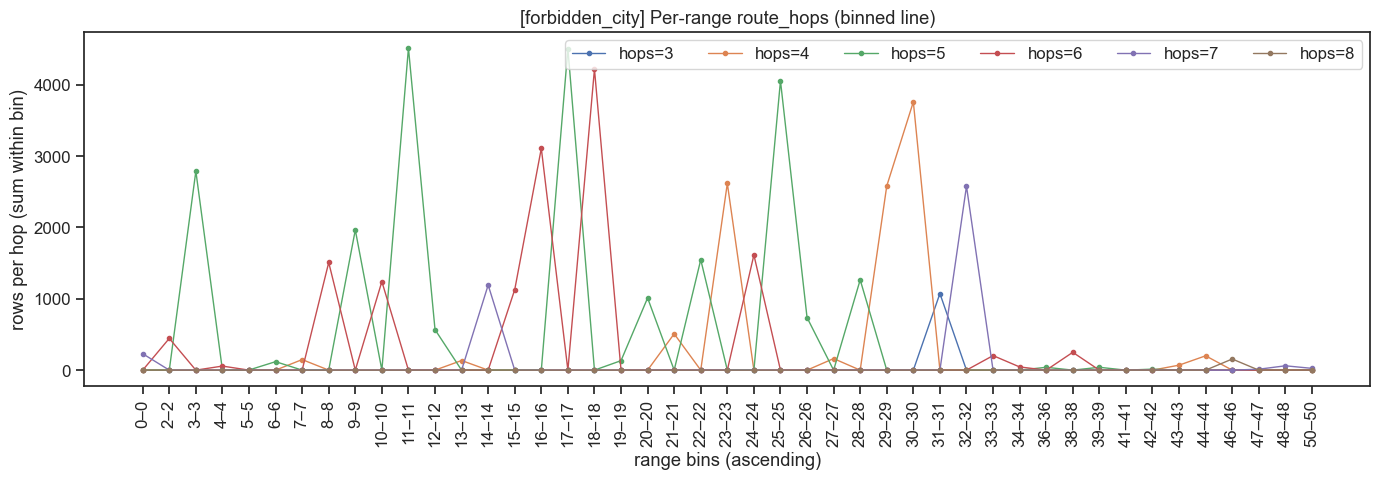


=== compact plotting for beijing ===


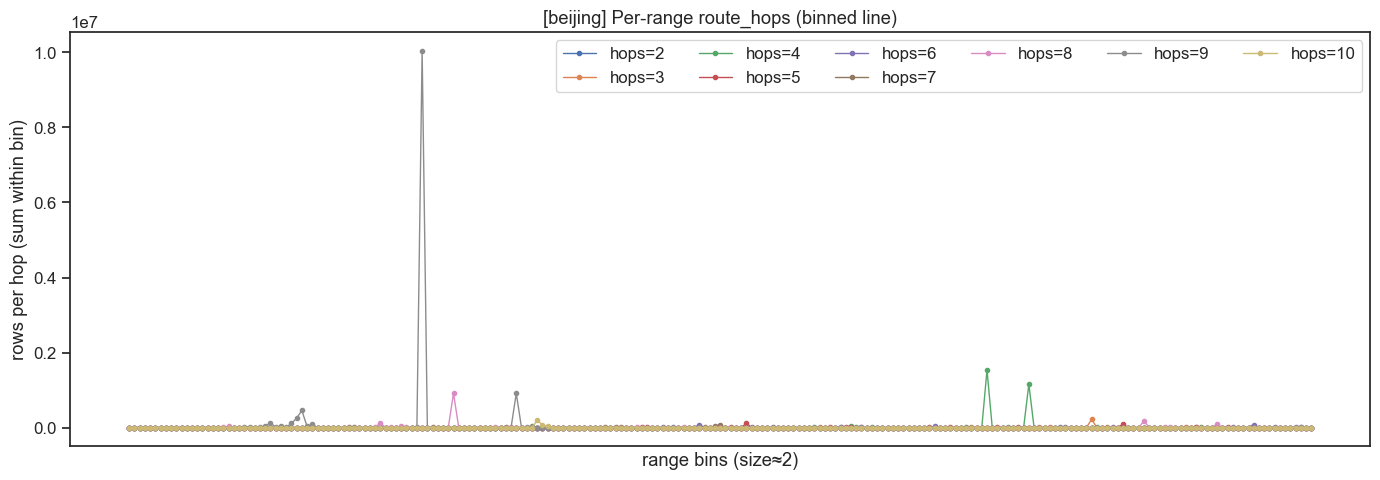

In [41]:
def make_bins(ranges:list[int], target:int):
    """把 range（升序）分成 <= target 个等量桶，返回 (bin_id_by_range, bin_labels)"""
    n = len(ranges)
    bin_size = max(1, int(math.ceil(n / target)))
    # 按“位置”分桶更稳健（即使 range_idx 不是连续整数也没关系）
    pos = pd.Series(range(n), index=ranges)
    bin_ids = (pos // bin_size).astype(int)
    # 每个桶的标签使用区间的首尾 range 值，如 "120-139"
    labels = []
    for b, grp in bin_ids.groupby(bin_ids):
        idxs = grp.index.to_list()
        labels.append(f"{idxs[0]}–{idxs[-1]}")
    return bin_ids, labels, bin_size

def plot_compact_for_query(name:str, df:pd.DataFrame):
    # 统一升序
    ranges = sorted(df["range_idx"].dropna().astype(int).unique().tolist())
    if not ranges:
        print(f"[WARN] {name}: no ranges found.")
        return

    # --- 生成分桶映射 ---
    bin_ids, bin_labels, bin_size = make_bins(ranges, TARGET_POINTS)
    B = bin_ids.max() + 1
    x = np.arange(B)

    # === 图1：每个桶的“跳数折线图”（每条线是一个 hop，在桶内对行数求和）===
    hops_df = df[["range_idx", "route_hops"]].dropna()
    hops_df["range_idx"] = hops_df["range_idx"].astype(int)
    hops_df["route_hops"] = hops_df["route_hops"].astype(int)

    # 先按 (range_idx, hop) 计数，再映射到桶并对桶求和
    hop_counts = hops_df.groupby(["range_idx", "route_hops"]).size().rename("cnt").reset_index()
    hop_counts["bin"] = hop_counts["range_idx"].map(bin_ids.to_dict())
    hop_bin = hop_counts.groupby(["bin", "route_hops"])["cnt"].sum().unstack(fill_value=0).sort_index()

    plt.figure(figsize=(MAX_FIG_WIDTH, 5))
    for h in hop_bin.columns.tolist():
        plt.plot(x, hop_bin[h].values, marker=".", linewidth=1, label=f"hops={h}")
    if name == "beijing":
        plt.xticks([])  # 隐藏刻度，避免过长
        plt.xlabel(f"range bins (size≈{bin_size})")
    else:
        plt.xticks(x, bin_labels, rotation=90)
        plt.xlabel("range bins (ascending)")
    plt.ylabel("rows per hop (sum within bin)")
    plt.title(f"[{name}] Per-range route_hops (binned line)")
    plt.legend(ncol=min(6, hop_bin.shape[1]))
    plt.tight_layout()
    plt.show()
for name, df in dfs.items():
    print(f"\n=== compact plotting for {name} ===")
    plot_compact_for_query(name, df)

### Figure B: Nodes touched per range (binned average)
This bar chart reports the average node cover per bin, i.e., the average number of distinct physical nodes (`pnode_idx`) reached by ranges within each bin.

- **X-axis:** Range bins in ascending order (x-ticks hidden for *beijing*).
- **Y-axis:** Nodes touched (average per bin).

**How to read:** Lower bars indicate ranges tend to be served by fewer nodes (better locality and lower coordination cost).  
**Why it matters:** Large values imply wide fan-out across nodes. Consider co-location, adjusting `stop_tail_bits` / `merge_gap_keys`, or using (smart) virtual nodes to reduce cross-node traffic.



=== compact plotting for forbidden_city ===


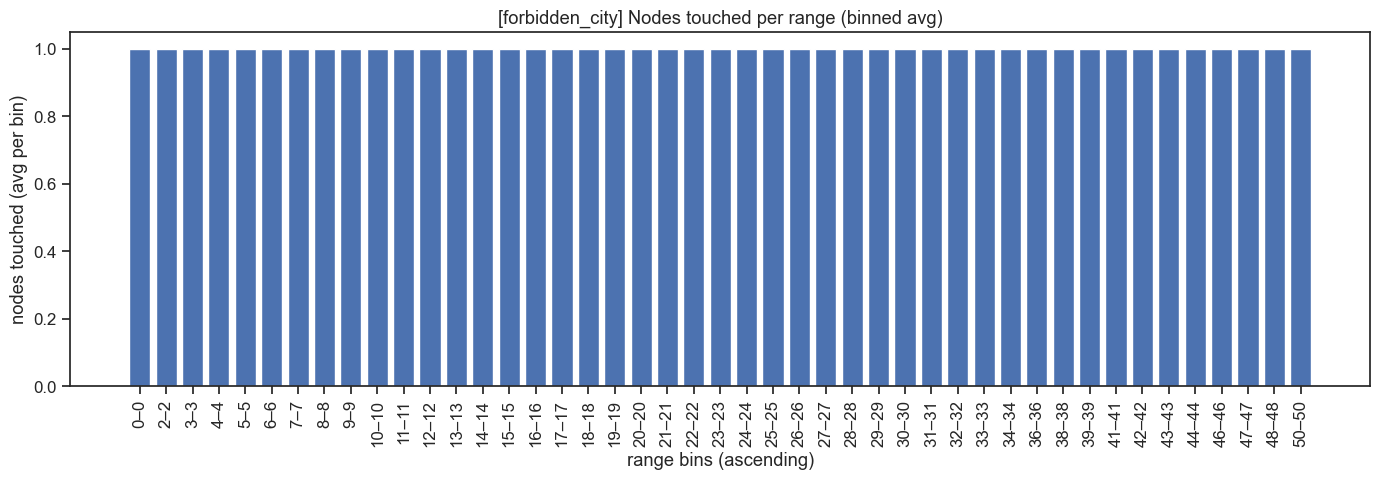


=== compact plotting for beijing ===


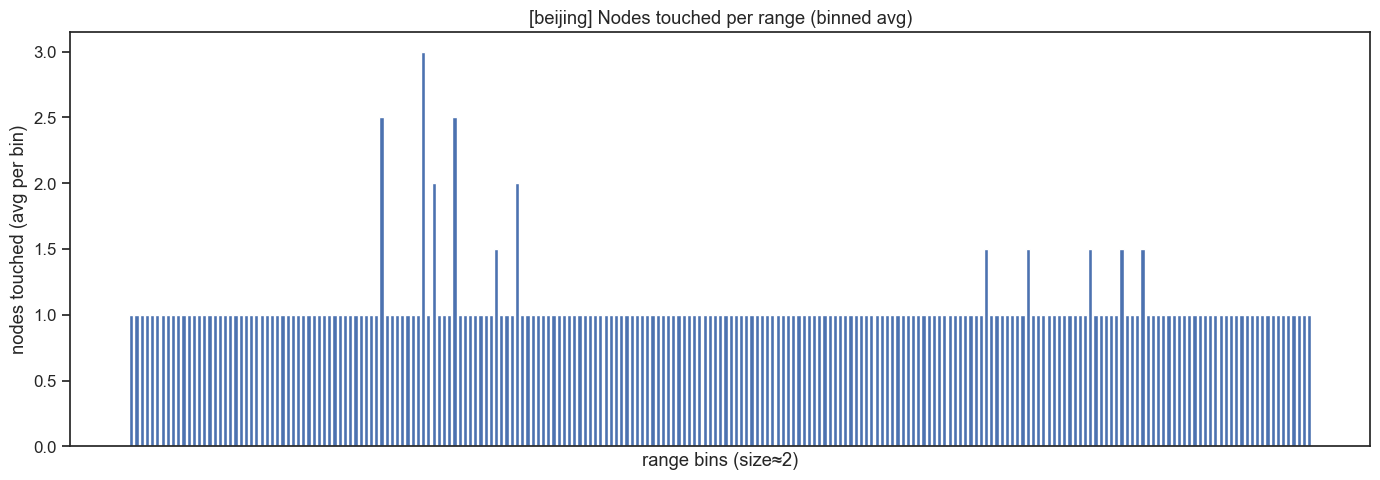

In [42]:
def plot_compact_for_query(name:str, df:pd.DataFrame):
    # 统一升序
    ranges = sorted(df["range_idx"].dropna().astype(int).unique().tolist())
    if not ranges:
        print(f"[WARN] {name}: no ranges found.")
        return

    # --- 生成分桶映射 ---
    bin_ids, bin_labels, bin_size = make_bins(ranges, TARGET_POINTS)
    B = bin_ids.max() + 1
    x = np.arange(B)

    # === 图2：每个桶的 node cover（桶内取“平均”）===
    cover = df.groupby("range_idx")["pnode_idx"].nunique().reindex(ranges).fillna(0).astype(float)
    cover_df = pd.DataFrame({"range_idx": ranges, "cover": cover.values})
    cover_df["bin"] = cover_df["range_idx"].map(bin_ids.to_dict())
    cover_bin = cover_df.groupby("bin")["cover"].mean()

    plt.figure(figsize=(MAX_FIG_WIDTH, 5))
    plt.bar(x, cover_bin.values)
    if name == "beijing":
        plt.xticks([])
        plt.xlabel(f"range bins (size≈{bin_size})")
    else:
        plt.xticks(x, bin_labels, rotation=90)
        plt.xlabel("range bins (ascending)")
    plt.ylabel("nodes touched (avg per bin)")
    plt.title(f"[{name}] Nodes touched per range (binned avg)")
    plt.tight_layout()
    plt.show()
for name, df in dfs.items():
    print(f"\n=== compact plotting for {name} ===")
    plot_compact_for_query(name, df)

### Figure C: Rows produced per range (binned sum)
This bar chart shows the total number of result rows produced within each range bin (sum of hits inside the bin).

- **X-axis:** Range bins in ascending order (x-ticks hidden for *beijing*).
- **Y-axis:** Rows (sum per bin).

**How to read:** Taller bars indicate hot ranges concentrated in that bin.  
**Why it matters:** Hot ranges can cause load skew and tail latency. Consider caching, finer partitioning for those ranges, or replication/sharding strategies to spread the load.



=== compact plotting for forbidden_city ===


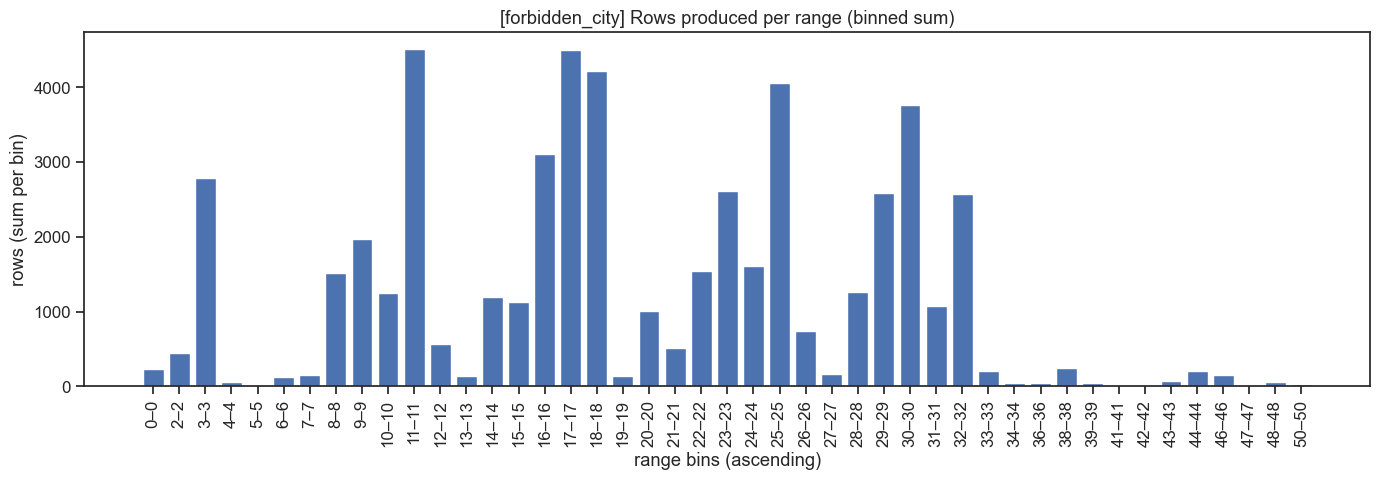

[forbidden_city] binning: 45 ranges -> 45 bins (bin_size≈1)

=== compact plotting for beijing ===


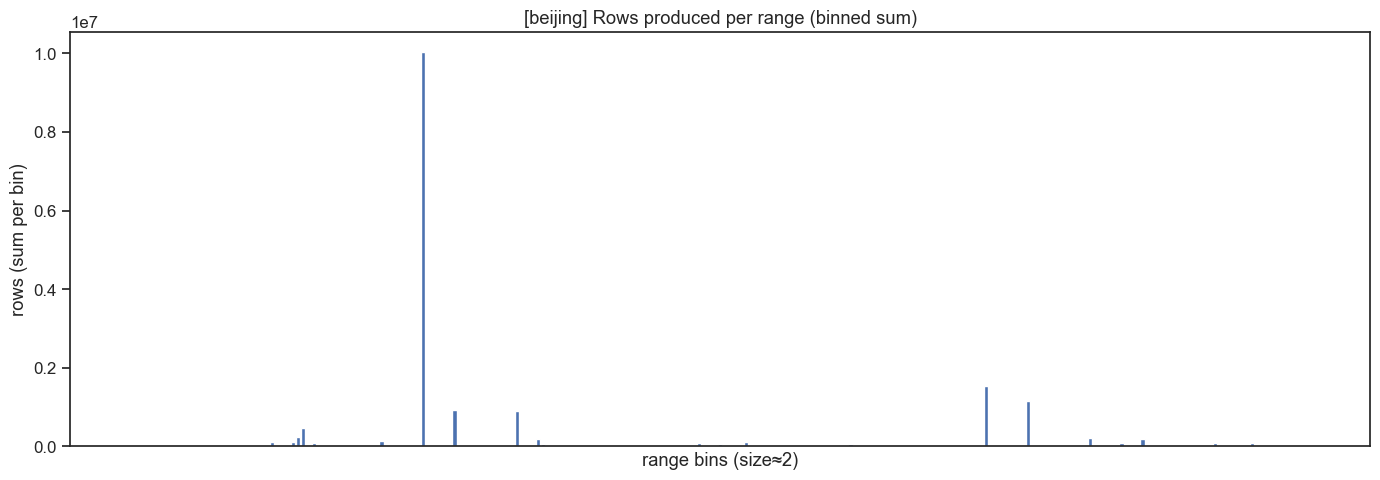

[beijing] binning: 453 ranges -> 227 bins (bin_size≈2)


In [43]:
def plot_compact_for_query(name:str, df:pd.DataFrame):
    # 统一升序
    ranges = sorted(df["range_idx"].dropna().astype(int).unique().tolist())
    if not ranges:
        print(f"[WARN] {name}: no ranges found.")
        return

    # --- 生成分桶映射 ---
    bin_ids, bin_labels, bin_size = make_bins(ranges, TARGET_POINTS)
    B = bin_ids.max() + 1
    x = np.arange(B)

    # === 图3：每个桶的 hits（桶内求“和”）===
    hits = df.groupby("range_idx").size().reindex(ranges).fillna(0).astype(int)
    hits_df = pd.DataFrame({"range_idx": ranges, "hits": hits.values})
    hits_df["bin"] = hits_df["range_idx"].map(bin_ids.to_dict())
    hits_bin = hits_df.groupby("bin")["hits"].sum()

    plt.figure(figsize=(MAX_FIG_WIDTH, 5))
    plt.bar(x, hits_bin.values)
    if name == "beijing":
        plt.xticks([])
        plt.xlabel(f"range bins (size≈{bin_size})")
    else:
        plt.xticks(x, bin_labels, rotation=90)
        plt.xlabel("range bins (ascending)")
    plt.ylabel("rows (sum per bin)")
    plt.title(f"[{name}] Rows produced per range (binned sum)")
    plt.tight_layout()
    plt.show()

    print(f"[{name}] binning: {len(ranges)} ranges -> {B} bins (bin_size≈{bin_size})")

for name, df in dfs.items():
    print(f"\n=== compact plotting for {name} ===")
    plot_compact_for_query(name, df)